In [1]:
import inspect

from nvidia.dali.pipeline import experimental, pipeline_def
from nvidia.dali.types import DALIDataType
from nvidia.dali import fn
from nvidia.dali import types
from nvidia.dali import tensors

from nvidia.dali.data_node import DataNode as _DataNode

from functools import wraps

import numpy as np

# dynamic and static magnitude [done]
# negation of the range [done]
# magnitudes range - tuple, list or cb [done]
# extra params [done]
# fixed-point closure?
# add can negate to mag inference

In [2]:
def x(a, b, c=None, **kw):
    return c

inspect.getfullargspec(x).args

['a', 'b', 'c']

In [3]:
# data_path = "/home/ktokarski/DALI_extra/db/single/singleclass"
data_path = "/home/ktokarski/DALI_extra/db/single/jpeg"


import os
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def display_imgs(outputs, columns=2, captions=None, cpu=True):
    rows = (len(outputs) + columns - 1) // columns
    fig = plt.figure()
    fig.set_size_inches(16, 6 * rows)
    gs = gridspec.GridSpec(rows, columns)
    row = 0
    col = 0
    for i in range(len(outputs)):
        plt.subplot(gs[i])
        plt.axis("off")
        if captions is not None:
            plt.title(captions[i])
        if hasattr(outputs, 'at'):
            out = outputs.at(i) if cpu else outputs.as_cpu().at(i)
        else:
            out = outputs[i]
        if len(out.shape) == 2 or (len(out.shape) == 3 and out.shape[-1] == 1):
            plt.imshow(out, cmap='gray')
        else:
            plt.imshow(out)

In [4]:
def as_param_(mag):
    return np.array(mag)


def get_magnitude_range(magnitudes, num_bins):
    if magnitudes is None:
        return np.full(num_bins, 0, dtype=np.float32)
    if callable(magnitudes):
        magnitudes = magnitudes(num_bins)
    if isinstance(magnitudes, tuple) and len(magnitudes) == 2:
        lo, hi = magnitudes
        return np.linspace(lo, hi, num_bins, dtype=np.float32)
    if len(magnitudes) != num_bins:
        raise Exception(f"Got magnitude range of length {len(mag_range)} while the num_bins specified is {num_bins}.")
    return magnitudes


def call_with_extra(fun, extra):
    def inner(*args):
        fun_args = inspect.getfullargspec(fun).args
        kwargs = {
            name: param
            for name, param in extra.items()
            if name in fun_args
        }
        print(fun_args, kwargs)
        return fun(*args, **kwargs)
    return inner


def augmentation(function=None, mag_range=None, as_param=None,
                 can_negate=False, param_dev="cpu", enforce_data_node=False):
    if as_param is None:
        as_param = as_param_
    augmentation_params = {
        'can_negate': can_negate
    }
    def decorator(function):
        @wraps(function)
        def wrapper(samples, bin_idx, num_bins, mag_to_param_range, extra):
            as_param_extra = call_with_extra(as_param, extra)
            if callable(mag_range):
                mag_range_extra = call_with_extra(mag_range, extra)
            else:
                mag_range_extra = mag_range
            magnitudes = get_magnitude_range(mag_range_extra, num_bins)
            if not isinstance(bin_idx, _DataNode):
                param = np.array(as_param_extra(magnitudes[bin_idx]))
                if enforce_data_node or param_dev == "gpu":
                    param = types.Constant(param, device=param_dev)
            else:
                params = mag_to_param_range(magnitudes, as_param, can_negate)
                params = types.Constant(params, device=param_dev)
                param = params[bin_idx]
                
            return call_with_extra(function, extra)(samples, param)
        setattr(wrapper, '_augmentation_params', augmentation_params)
        return wrapper
    if function is None:
        return decorator
    else:
        return decorator(function)

In [5]:
# def warp_x_param(magnitude):
#     return [magnitude, 0]

# def warp_y_param(magnitude):
#     return [0, magnitude]

# @augmentation(can_negate=True, as_param=warp_x_param)
# def shear_x(samples, parameter):
#     mt = fn.transforms.shear(shear=parameter)
#     return fn.warp_affine(samples, matrix=mt, fill_value=0, inverse_map=False)

# @augmentation(can_negate=True, as_param=warp_y_param)
# def shear_y(samples, parameter, extra):
#     mt = fn.transforms.shear(shear=parameter)
#     return fn.warp_affine(samples, matrix=mt, fill_value=0, inverse_map=False)

# @augmentation(can_negate=True, as_param=warp_x_param)
# def translate_x(samples, parameter, shapes):
#     mt = fn.transforms.translation(offset=parameter)    
#     return fn.warp_affine(samples, matrix=mt, fill_value=0, inverse_map=False)

# @augmentation(can_negate=True, as_param=warp_x_param)
# def translate_x_shape(samples, parameter, shapes):
#     max_offset = shapes[-3:-2]
#     parameter *= max_offset
#     mt = fn.transforms.translation(offset=parameter)    
#     return fn.warp_affine(samples, matrix=mt, fill_value=0, inverse_map=False)

# @augmentation(can_negate=True, as_param=warp_y_param)
# def translate_y(samples, parameter):
#     mt = fn.transforms.translation(offset=parameter)
#     return fn.warp_affine(samples, matrix=mt, fill_value=0, inverse_map=False)

# @augmentation(can_negate=True, as_param=warp_y_param)
# def translate_y_shape(samples, parameter, shapes):
#     max_offset = shapes[-3:-2]
#     parameter *= max_offset
#     mt = fn.transforms.translation(offset=parameter)
#     return fn.warp_affine(samples, matrix=mt, fill_value=0, inverse_map=False)

# @augmentation(can_negate=True)
# def rotate(samples, parameter):
#     return fn.rotate(samples, angle=parameter, fill_value=0)

# @augmentation(can_negate=True)
# def brightness(samples, parameter):
#     return fn.brightness(samples, brightness=parameter)

# @augmentation(can_negate=True)
# def contrast(samples, parameter):
#     return fn.contrast(samples, contrast=parameter)

# @augmentation(can_negate=True)
# def color(samples, parameter):
#     return fn.saturation(samples, saturation=parameter)

# def sharpness_param(magnitude):
#     blur = np.array([
#         [1, 1, 1],
#         [1, 5, 1],
#         [1, 1, 1]],
#         dtype=np.float32) / 13
#     ident = np.array([
#         [0, 0, 0],
#         [0, 1, 0],
#         [0, 0, 0]],
#         dtype=np.float32)
#     return -magnitude * blur + (1 + magnitude) * ident

# @augmentation(can_negate=True, as_param=sharpness_param, param_dev="gpu")
# def sharpness(samples, kernel):
#     return fn.experimental.filter(samples, kernel)

# def posterize_param(magnitude):
#     nbits = np.round(magnitude).astype(np.int32)
#     return np.array(255 ^ (2 ** nbits - 1), dtype=np.uint8)

# @augmentation(mag_range=(1, 4), as_param=posterize_param, param_dev="gpu")
# def posterize(samples, mask):
#     return samples & mask

# @augmentation(mag_range=(256, 0), param_dev="gpu")
# def solarize(samples, threshold):
#     samples_inv = 255 - samples
#     mask_unchanged = samples < threshold
#     mask_inverted = 1 - mask_unchanged
#     return fn.cast_like(mask_unchanged * samples + mask_inverted * samples_inv, samples)

# @augmentation(mag_range=(0, 110), param_dev="gpu")
# def solarize_add(samples, shift):
#     samples_shifted = fn.cast_like(samples + shift, samples)
#     mask_left = samples < 128
#     mask_right = 1 - mask_left
#     return fn.cast_like(mask_left * samples_shifted + mask_right * samples, samples)

# @augmentation
# def invert(samples, _):
#     return fn.cast_like(255 - samples, samples)

# @augmentation
# def equalize(samples, _):
#     return fn.experimental.equalize(samples)

# @augmentation
# def autocontrast(samples, _):
#     lo, hi = fn.reductions.min(samples, axes=[-3, -2]), fn.reductions.max(samples, axes=[-3, -2])
#     lo = fn.expand_dims(lo, axes=[0, 1])
#     hi = fn.expand_dims(hi, axes=[0, 1])
#     return fn.cast_like((samples - lo) * (255 / (hi - lo)), samples)

In [6]:
def warp_x_param(magnitude):
    return [magnitude, 0]

@augmentation(mag_range=(0, 0.3), can_negate=True, as_param=warp_x_param)
def shear_x(samples, parameter):
    mt = fn.transforms.shear(shear=parameter)
    return fn.warp_affine(samples, matrix=mt, fill_value=0, inverse_map=False)

def warp_y_param(magnitude):
    return [0, magnitude]

@augmentation(mag_range=(0, 0.3), can_negate=True, as_param=warp_y_param)
def shear_y(samples, parameter):
    mt = fn.transforms.shear(shear=parameter)
    return fn.warp_affine(samples, matrix=mt, fill_value=0, inverse_map=False)

# def translate_magnitude(num_bins, shapes=None):
#     if shapes is not None:
#         return (0, 0.45)
#     else:
#         return (0, 250)

@augmentation(mag_range=(0, 0.45), can_negate=True, as_param=warp_x_param)
def translate_x(samples, parameter, shapes=None):
    if shapes is not None:
        print("not none x")
        max_offset = shapes[-3:-2]
        parameter *= max_offset
    mt = fn.transforms.translation(offset=parameter)    
    return fn.warp_affine(samples, matrix=mt, fill_value=0, inverse_map=False)

@augmentation(mag_range=(0, 0.45), can_negate=True, as_param=warp_y_param)
def translate_y(samples, parameter, shapes=None):
    if shapes is not None:
        print("not none y")
        max_offset = shapes[-3:-2]
        parameter *= max_offset
    mt = fn.transforms.translation(offset=parameter)
    return fn.warp_affine(samples, matrix=mt, fill_value=0, inverse_map=False)

@augmentation(mag_range=(0, 30), can_negate=True)
def rotate(samples, parameter):
    return fn.rotate(samples, angle=parameter, fill_value=0)

# For color operations the neutral magnitude is 1, while
# the closer the value is to 0 and 2, the strongest the effect
# of the operation is. Given magnitude : (±1) * [0, 1],
# use it to move away from the neutral param.
def shift_color_range(magnitude):
    return 1 + magnitude

@augmentation(mag_range=(0.1, 0.9), can_negate=True, as_param=shift_color_range)
def brightness(samples, parameter):
    return fn.brightness(samples, brightness=parameter)

@augmentation(mag_range=(0.1, 0.9), can_negate=True, as_param=shift_color_range)
def contrast(samples, parameter):
    return fn.contrast(samples, contrast=parameter)

@augmentation(mag_range=(0.1, 1), can_negate=True, as_param=shift_color_range)
def color(samples, parameter):
    return fn.saturation(samples, saturation=parameter)

def sharpness_param(magnitude):
    blur = np.array([
        [1, 1, 1],
        [1, 5, 1],
        [1, 1, 1]],
        dtype=np.float32) / 13
    ident = np.array([
        [0, 0, 0],
        [0, 1, 0],
        [0, 0, 0]],
        dtype=np.float32)
    return -magnitude * blur + (1 + magnitude) * ident

@augmentation(mag_range=(0.1, 1), can_negate=True, as_param=sharpness_param, param_dev="gpu")
def sharpness(samples, kernel):
    return fn.experimental.filter(samples, kernel)

def posterize_param(magnitude):
    nbits = np.round(magnitude).astype(np.int32)
    return np.array(255 ^ (2 ** nbits - 1), dtype=np.uint8)

@augmentation(mag_range=(1, 4), as_param=posterize_param, param_dev="gpu")
def posterize(samples, mask):
    return samples & mask

@augmentation(mag_range=(256, 0), param_dev="gpu")
def solarize(samples, threshold):
    samples_inv = 255 - samples
    mask_unchanged = samples < threshold
    mask_inverted = 1 - mask_unchanged
    return fn.cast_like(mask_unchanged * samples + mask_inverted * samples_inv, samples)

@augmentation(mag_range=(0, 110), param_dev="gpu")
def solarize_add(samples, shift):
    samples_shifted = fn.cast_like(samples + shift, samples)
    mask_left = samples < 128
    mask_right = 1 - mask_left
    return fn.cast_like(mask_left * samples_shifted + mask_right * samples, samples)

@augmentation
def invert(samples, _):
    return fn.cast_like(255 - samples, samples)

@augmentation
def equalize(samples, _):
    return fn.experimental.equalize(samples)

@augmentation
def autocontrast(samples, _):
    lo, hi = fn.reductions.min(samples, axes=[-3, -2]), fn.reductions.max(samples, axes=[-3, -2])
    lo = fn.expand_dims(lo, axes=[0, 1])
    hi = fn.expand_dims(hi, axes=[0, 1])
    return fn.cast_like((samples - lo) * (255 / (hi - lo)), samples)

In [7]:
def get_operations(num_total_ops, num_levels=1):
    shape = tuple() if num_levels == 1 else (num_levels,)
    rng = np.random.default_rng(12345)
    def inner(sample_info):
        return rng.choice(range(num_total_ops), shape)
    return inner

def split_level(op_range_lo, op_range_hi, ops, level_op_idx, op_kwargs):
    assert op_range_lo <= op_range_hi
    if op_range_lo == op_range_hi:
        return ops[op_range_lo](**op_kwargs)
    mid = (op_range_lo + op_range_hi) // 2
    if level_op_idx <= mid:
        return split_level(op_range_lo, mid, ops, level_op_idx, op_kwargs)
    else:
        return split_level(mid + 1, op_range_hi, ops, level_op_idx, op_kwargs)
    
def op_aug_params(op):
    return getattr(op, '_augmentation_params')

def get_signed_magnitude(magnitudes, can_negate, bin_idx):
    magnitude = magnitudes[bin_idx // 2]
    if can_negate and bin_idx % 2:
        magnitude = -magnitude
    return np.array(magnitude, dtype=magnitudes.dtype)

def map_random_unsigned_bin(magnitudes, as_param, can_negate):
    return np.array([as_param(magnitude) for magnitude in magnitudes])

def map_random_signed_bin(magnitudes, as_param, can_negate):
    return np.array([
            as_param(get_signed_magnitude(magnitudes, can_negate, bin_idx))
            for bin_idx in range(len(magnitudes) * 2)
        ])

def map_fixed_signed_bin(fixed_bin_idx):
    def inner(magnitudes, as_param, can_negate):
        magnitudes = magnitudes[fixed_bin_idx:fixed_bin_idx+2]
        return np.array([
            as_param(get_signed_magnitude(magnitudes, can_negate, bin_idx))
            for bin_idx in range(2)
        ])
    return inner


def setup_magnitudes(num_bins, use_signed_magnitudes, fixed_bin=None, num_levels=1):
    assert not isinstance(fixed_bin, _DataNode)
    shape = tuple() if num_levels == 1 else (num_levels,)
    if fixed_bin is not None:
        if not use_signed_magnitudes:
            return fixed_bin, None
        else:
            bin_idx = fn.random.uniform(range=[0, 1], dtype=types.INT32, shape=shape)
            return bin_idx, map_fixed_signed_bin(fixed_bin)
    else:
        if not use_signed_magnitudes:
            bin_idx = fn.random.uniform(range=[0, num_bins - 1], dtype=types.INT32, shape=shape)
            return bin_idx, map_random_unsigned_bin
        else:
            num_rand_bins = 2 * num_bins
            bin_idx = fn.random.uniform(range=[0, num_rand_bins - 1], dtype=types.INT32, shape=shape)
            return bin_idx, map_random_signed_bin


def trivial_augment(ops, samples, num_bins=31, use_sign=True, extra=None):
    num_total_ops = len(ops)
    use_signed_magnitudes = use_sign and any(op_aug_params(op)['can_negate'] for op in ops)
    bin_idx, mag_to_param_range = setup_magnitudes(num_bins, use_signed_magnitudes)
    op_idx = fn.external_source(source=get_operations(num_total_ops, 1), batch=False)
    op_kwargs = {
        "samples": samples,
        "bin_idx": bin_idx,
        "mag_to_param_range": mag_to_param_range,
        "num_bins": num_bins,
        "extra": extra or {}
    }
    samples = split_level(0, num_total_ops - 1, ops, op_idx, op_kwargs)
    return samples


def rand_augment(ops, samples, N, M, num_bins=31, use_sign=True, extra=None):
    num_total_ops = len(ops)
    use_signed_magnitudes = use_sign and any(op_aug_params(op)['can_negate'] for op in ops)
    bin_idx, mag_to_param_range = setup_magnitudes(
        num_bins, use_signed_magnitudes,
        fixed_bin=M, num_levels=N)
    op_kwargs = {
        "num_bins": num_bins,
        "extra": extra or {},
        "mag_to_param_range": mag_to_param_range,
    }
    op_idxs = fn.external_source(source=get_operations(num_total_ops, N), batch=False)
    for level_idx in range(N):
        op_kwargs = dict(samples=samples, bin_idx=bin_idx[level_idx], **op_kwargs)
        samples = split_level(0, num_total_ops - 1, ops, op_idxs[level_idx], op_kwargs)
        return samples


# def rand_augment(ops, samples, N, M, num_bins=31, use_sign=True, extra=None):
#     num_total_ops = len(ops)
#     use_signed_magnitudes = use_sign and any(op_aug_params(op)['can_negate'] for op in ops)
#     op_common_kwargs = {
#         "num_bins": num_bins,
#         "extra": extra or {}
#     }
#     # the magnitudes are trully fixed (i.e don't depend on any runtime values) 
#     if not use_signed_magnitudes:
#         bin_idx, mag_to_param_range = setup_magnitudes(num_bins, use_signed_magnitudes, M)
#         op_common_kwargs.update({
#             "bin_idx": bin_idx,
#             "mag_to_param_range": mag_to_param_range,
#         })
#     op_idxs = fn.external_source(source=get_operations(num_total_ops, N), batch=False)
#     for level_idx in range(N):
#         op_kwargs = dict(samples=samples, **op_common_kwargs)
#         if use_signed_magnitudes:
#             bin_idx, mag_to_param_range = setup_magnitudes(num_bins, use_signed_magnitudes, M)
#             op_kwargs.update({
#                 "bin_idx": bin_idx,
#                 "mag_to_param_range": mag_to_param_range,
#             })
#         samples = split_level(0, num_total_ops - 1, ops, op_idxs[level_idx], op_kwargs)
#     return samples

In [8]:
# trivial_aug_ops = [shear_x, shear_y, translate_x, translate_y, rotate, brightness, contrast, color, posterize, solarize, solarize_add, sharpness, invert, equalize, autocontrast]

# trivial_aug_ops = [shear_x, shear_y, translate_x, translate_y]

trivial_aug_ops = [translate_x, translate_y]



@experimental.pipeline_def(enable_conditionals=True, seed=42)
def pipeline():
    images, _ = fn.readers.file(name="Reader", file_root=data_path, random_shuffle=True, seed=42)
    shapes = fn.peek_image_shape(images)
    extra = {"shapes": shapes}
    images = fn.decoders.image(images, device="mixed")
#     images = fn.resize(images, resize_x=400, resize_y=400)
#     extra = {}
    return trivial_augment(trivial_aug_ops, images, extra=extra, use_sign=True)
#     return rand_augment(trivial_aug_ops, images, 10, 25, extra={"shape": shapes}, use_sign=True)

In [9]:
p = pipeline(batch_size=30, device_id=0, num_threads=4)

['samples', 'parameter', 'shapes'] {'shapes': DataNode(name="__Split_12[0]", device="cpu")}
not none x
['samples', 'parameter', 'shapes'] {'shapes': DataNode(name="__Split_12[1]", device="cpu")}
not none y


In [10]:
p.build()
# p.save_graph_to_dot_file("hmhmhm.dot")

In [11]:
out, = p.run()

In [12]:
out = [np.array(s) for s in out.as_cpu()]

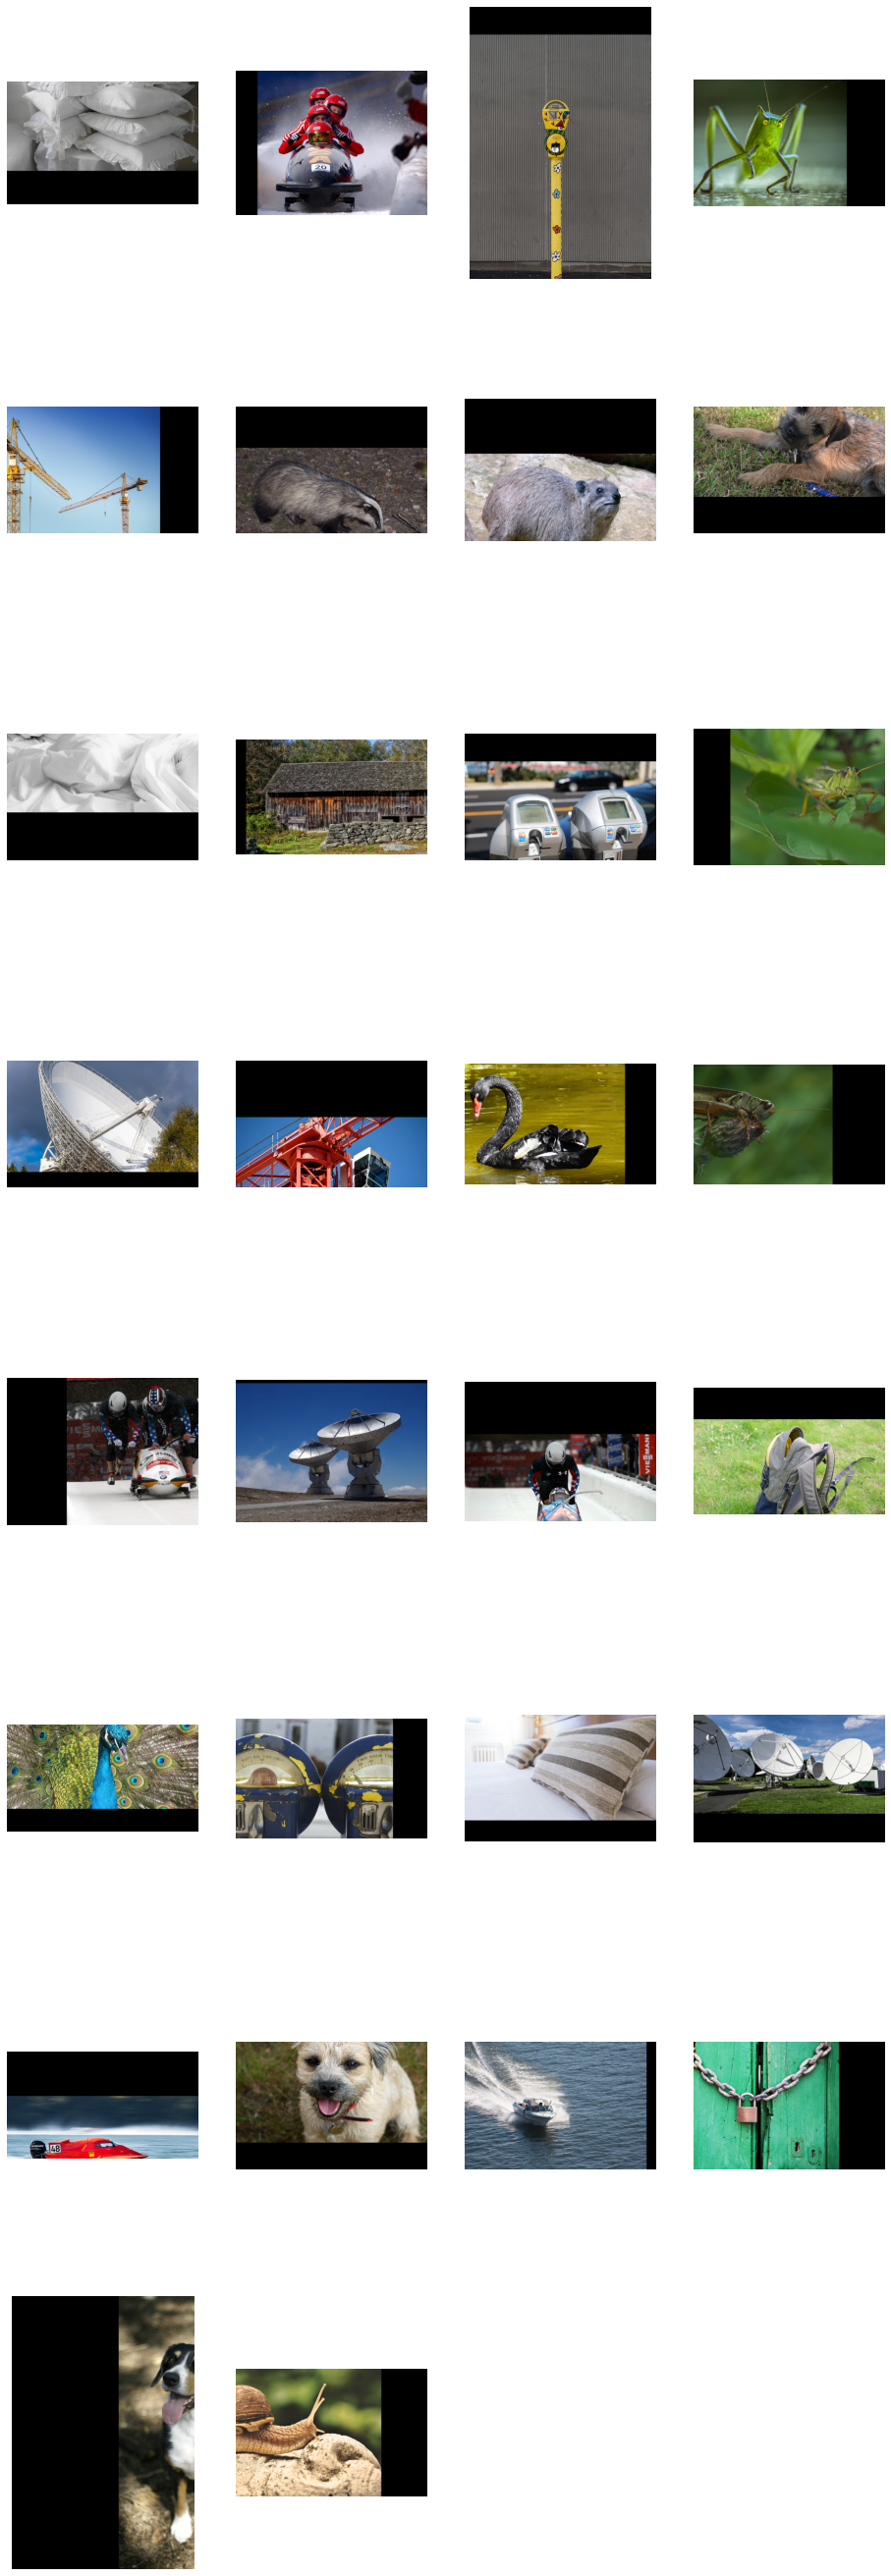

In [13]:
display_imgs(out, columns=4)